In [26]:
from scripts import plugin_loader  # noqa: F401
import matplotlib.pyplot as plt

In [27]:
from pathlib import Path

images_directory = "../images/"
annotations_directory = "../images/annotated/"
processed_directory = "../processed/"


def get_file_name_from_stem(directory: str, target_stem: str) -> str | None:
    search_directory = Path(directory)
    files = [f for f in search_directory.glob(f"{target_stem}.*") if f.is_file()]

    if files is None or len(files) < 1:
        print(f"No file with stem {target_stem} exists.")
        return None

    if len(files) > 1:
        print(
            f"Multiple files exist with stem {target_stem}. Please resolve these names."
        )
        return None

    return files[0].name

## Testing Environment
Defines environment variables required for testing.
- `images_directory`: directory to search for test images
- `annotations_directory`: directory to search for related annotation segmentation masks (denotes ground truth)
- `images`: dictionary holding test image to ground truth mappings
- `methods`: set of methods to test with the dispatcher in `PyProcessor`

In [28]:
images = {}


def add_image_annotation_from_range(start: int, end: int) -> None:
    assert start >= 0 and end >= start and end < 9999
    for stem in range(start, end + 1):
        stem_str: str = f"{stem:04}"

        image_path = get_file_name_from_stem(images_directory, stem_str)
        annotation_path = get_file_name_from_stem(annotations_directory, stem_str)

        if image_path is None or annotation_path is None:
            continue

        images[image_path] = annotation_path


add_image_annotation_from_range(1, 169)

methods = {
    "mfccd",
    "mfgamma",
    "mfsigmoid",
    "mfhyst",
    "mfhgamma",
    "mfhsigmoid",
    "fmm",
    "smf",
    "pmf",
}

No file with stem 0039 exists.
No file with stem 0040 exists.
No file with stem 0041 exists.
No file with stem 0042 exists.
No file with stem 0043 exists.
No file with stem 0044 exists.
No file with stem 0045 exists.
No file with stem 0046 exists.
No file with stem 0047 exists.
No file with stem 0048 exists.
No file with stem 0048 exists.
No file with stem 0049 exists.
No file with stem 0049 exists.
No file with stem 0050 exists.
No file with stem 0050 exists.
No file with stem 0051 exists.
No file with stem 0051 exists.
No file with stem 0052 exists.
No file with stem 0052 exists.
No file with stem 0053 exists.
No file with stem 0053 exists.
No file with stem 0054 exists.
No file with stem 0055 exists.
No file with stem 0056 exists.
No file with stem 0057 exists.
No file with stem 0058 exists.
No file with stem 0058 exists.
No file with stem 0076 exists.
No file with stem 0090 exists.
No file with stem 0091 exists.
No file with stem 0092 exists.
No file with stem 0093 exists.
No file 

## Scoring Logic
Iterates over the image-annotation pairs within the `images` dictionary and processes each image according to each method denoted in the `methods` set. The results are scored based on the annotation (ground truth):
- Intersection over Union: approximation of worst-case performance
- Dice: approximation of average-case performance
- Percent error: total number of false positives and false negatives

In [29]:
from joblib import Memory
import pandas as pd
import seaborn as sns
from utils import benchmark

cache_directory = "./__segcache__"
memory = Memory(cache_directory, verbose=0)

results = []

for image_path, annotation_path in images.items():
    for method in methods:
        # UNCOMMENT TO RERUN
        # benchmark.call(
        #     image_path=image_path, annotation_path=annotation_path, method=method
        # )

        results.append(benchmark(image_path, annotation_path, method))


In [30]:
df = pd.DataFrame(results)
df


,image_path,method_name,iou,dice,percent_err
0,0001.tif,mfsigmoid,0.103107,0.186939,0.128951
1,0001.tif,pmf,0.214807,0.353648,0.056645
2,0001.tif,mfgamma,0.103107,0.186939,0.128951
3,0001.tif,smf,0.000000,0.000000,0.041368
4,0001.tif,mfhsigmoid,0.103107,0.186939,0.128951
...,...,...,...,...,...
904,0169.jpg,mfhsigmoid,0.044248,0.084745,0.106032
905,0169.jpg,mfhgamma,0.116605,0.208856,0.026560
906,0169.jpg,mfhyst,0.028826,0.056036,0.177084
907,0169.jpg,mfccd,0.044248,0.084745,0.106032


## Metric Distributions
With the number of images we've tested, results grouped by metric alone varied widely. IoU and Dice appear evenly distributed along the range [0.0, 0.9). Later on in this notebook, we threshold our results to see when methods start to increase in performance.

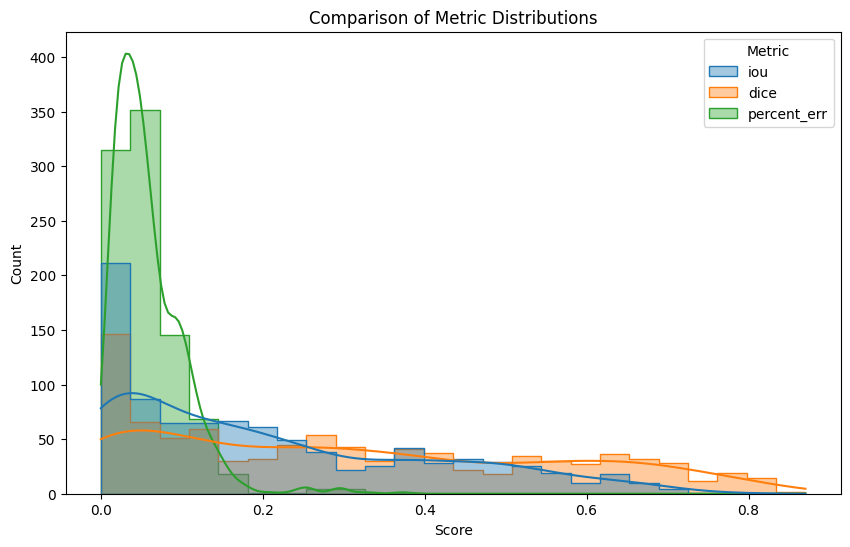

In [31]:
plt.figure(figsize=(10, 6))

# "melt" dataframe to make it compatible with Seaborn's multi-plot logic
df_melted = df.melt(
    value_vars=["iou", "dice", "percent_err"], var_name="Metric", value_name="Score"
)

# create the histogram with a KDE curve
sns.histplot(
    data=df_melted, x="Score", hue="Metric", kde=True, element="step", alpha=0.4
)

plt.title("Comparison of Metric Distributions")
plt.show()

## Method Distributions
Notice that the method type hardly played a factor in Dice score. Keep this in mind for later on.

Text(0.5, 0.98, 'Metric Performance by Method')

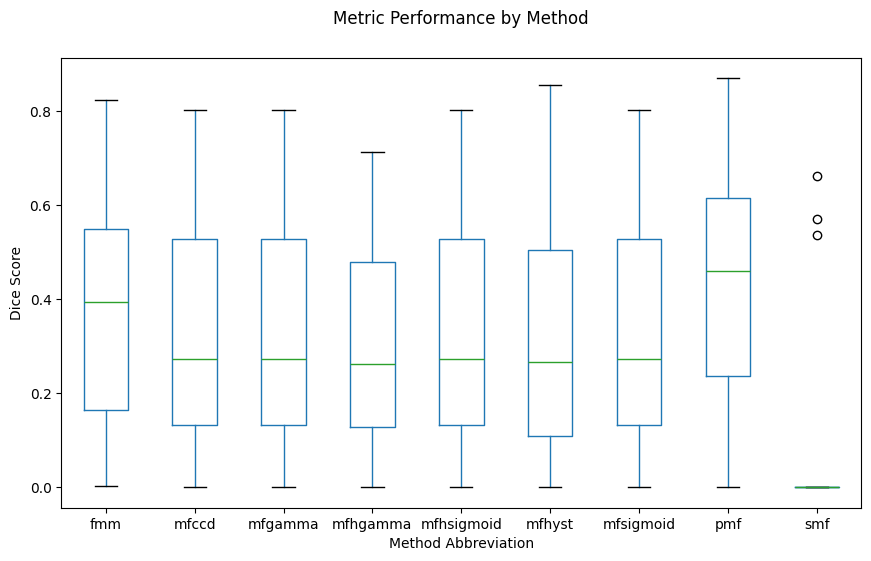

In [32]:
ax = df.boxplot(column="dice", by="method_name", figsize=(10, 6), grid=False)
ax.set(title=None)
ax.set_xlabel("Method Abbreviation")
ax.set_ylabel("Dice Score")
plt.suptitle("Metric Performance by Method")

In [33]:
method_performance = (
    df.groupby("method_name")[["iou", "dice", "percent_err"]]
    .mean()
    .sort_values(by="iou", ascending=False)
)
method_performance

,iou,dice,percent_err
method_name,,,
pmf,0.302764,0.430819,0.037002
fmm,0.259301,0.375688,0.044982
mfccd,0.220591,0.327836,0.070869
mfsigmoid,0.220591,0.327836,0.070869
mfgamma,0.220591,0.327836,0.070869
mfhsigmoid,0.220591,0.327836,0.070869
mfhyst,0.219668,0.322867,0.093069
mfhgamma,0.195185,0.297884,0.036751
smf,0.012463,0.017499,0.031733


## Pruning Results Based on IoU
Earlier in this notebook, we saw that IoU and Dice varied widely across all results. In order to get a better understanding why, it may be best to look at results with an IoU at or above a certain threshold.

> The plan is to find what kinds of images performed well, what kinds of images performed poorly, and what differentiates these two groups of images.

In [34]:
best_methods_per_image = (
    df.loc[df.groupby("image_path")["iou"].idxmax()]
    .set_index("image_path")
    .sort_values(by="iou", ascending=False)
)
best_methods_per_image

,method_name,iou,dice,percent_err
image_path,,,,
0070.bmp,pmf,0.770401,0.870312,0.009084
0077.tif,mfhyst,0.748558,0.856201,0.016146
0098.tif,mfhyst,0.711939,0.831734,0.025036
0101.tif,mfhyst,0.708218,0.829190,0.024891
0165.jpg,pmf,0.686635,0.814207,0.008054
...,...,...,...,...
0160.jpg,pmf,0.079318,0.146978,0.057118
0146.tif,mfhgamma,0.047556,0.090794,0.124001
0147.tif,mfhgamma,0.027278,0.053107,0.040628


In [35]:
best_methods_per_image[best_methods_per_image.index.str.match("016[0-9].jpg")]

,method_name,iou,dice,percent_err
image_path,,,,
0165.jpg,pmf,0.686635,0.814207,0.008054
0161.jpg,pmf,0.525436,0.688900,0.015345
0162.jpg,pmf,0.440271,0.611372,0.013905
0167.jpg,pmf,0.420067,0.591616,0.007093
0166.jpg,pmf,0.404476,0.575981,0.012329
0163.jpg,pmf,0.375065,0.545524,0.011678
0168.jpg,pmf,0.368081,0.538098,0.007742
0169.jpg,pmf,0.209791,0.346822,0.011595
0164.jpg,pmf,0.192750,0.323202,0.028729


In [36]:
df_failed = best_methods_per_image[best_methods_per_image["iou"] < 0.40]
df_failed[~df_failed.index.str.match("016[0-9].jpg")].sort_index()

,method_name,iou,dice,percent_err
image_path,,,,
0001.tif,pmf,0.214807,0.353648,0.056645
0002.tif,mfhyst,0.367243,0.537202,0.056597
0003.tif,mfhyst,0.390145,0.561301,0.052034
0005.tif,pmf,0.346436,0.514597,0.034855
0008.tif,fmm,0.282050,0.439998,0.042139
0009.tif,mfsigmoid,0.185030,0.312280,0.066165
0011.tif,mfsigmoid,0.251465,0.401873,0.107258
0013.tif,fmm,0.250271,0.400347,0.054506
0014.tif,mfhyst,0.281594,0.439444,0.149142


In [37]:
df_pruned = best_methods_per_image[best_methods_per_image["iou"] >= 0.40]
df_pruned

,method_name,iou,dice,percent_err
image_path,,,,
0070.bmp,pmf,0.770401,0.870312,0.009084
0077.tif,mfhyst,0.748558,0.856201,0.016146
0098.tif,mfhyst,0.711939,0.831734,0.025036
0101.tif,mfhyst,0.708218,0.829190,0.024891
0165.jpg,pmf,0.686635,0.814207,0.008054
0104.tif,fmm,0.684899,0.812985,0.022236
0102.tif,fmm,0.674082,0.805316,0.023427
0099.tif,fmm,0.673501,0.804901,0.023781
0069.bmp,pmf,0.672805,0.804404,0.014233


In [38]:
from utils import compare
from typing import cast

for row in df_pruned.itertuples():
    image_str: str = cast(str, row.Index)
    method_str: str = cast(str, row.method_name)
    compare(
        image_str,
        images[image_str],
        method_str,
        output_directory="best"
    )

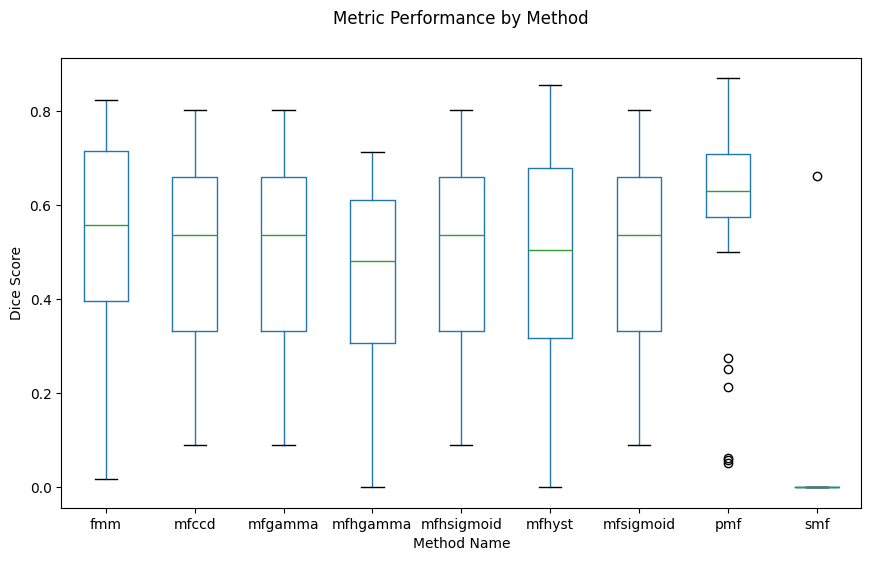

In [39]:
df_filtered = df[df["image_path"].isin(df_pruned.index)]
ax = df_filtered.boxplot(column="dice", by="method_name", figsize=(10, 6), grid=False)
ax.set(title=None)
ax.set_xlabel("Method Name")
ax.set_ylabel("Dice Score")
plt.suptitle("Metric Performance by Method")
plt.show()

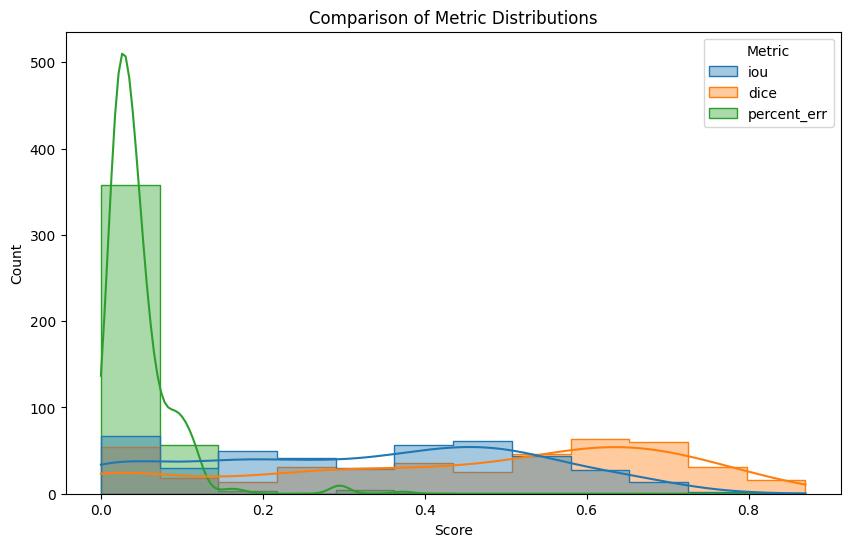

In [40]:
plt.figure(figsize=(10, 6))

df_filtered_melted = df_filtered.melt(
    value_vars=["iou", "dice", "percent_err"], var_name="Metric", value_name="Score"
)

sns.histplot(
    data=df_filtered_melted,
    x="Score",
    hue="Metric",
    kde=True,
    element="step",
    alpha=0.4,
)

plt.title("Comparison of Metric Distributions")
plt.show()

## Pyramid Matched Filter Results

Overall, it seems that the pyramid matched filter outperformed every other method in the majority of images.

Below are the results of just the pyramid matched filter.

In [41]:
pmf_results = df[df["method_name"] == "pmf"]

print("========== Intersection-over-Union Results ==========")
print(f"IoU High: {pmf_results['iou'].max():.2%}")
print(f"IoU Average: {pmf_results['iou'].mean():.2%}")
print(f"IoU Median: {pmf_results['iou'].median():.2%}")
print(f"IoU Low: {pmf_results['iou'].min():.2%}")
print()

print("========== Dice Score Results ==========")
print(f"Dice High: {pmf_results['dice'].max():.2%}")
print(f"Dice Average: {pmf_results['dice'].mean():.2%}")
print(f"Dice Median: {pmf_results['dice'].median():.2%}")
print(f"Dice Low: {pmf_results['dice'].min():.2%}")
print()

========== Intersection-over-Union Results ==========
IoU High: 77.04%
IoU Average: 30.28%
IoU Median: 29.94%
IoU Low: 0.00%

========== Dice Score Results ==========
Dice High: 87.03%
Dice Average: 43.08%
Dice Median: 46.09%
Dice Low: 0.00%



In [42]:
pmf_best = pmf_results[pmf_results["iou"] >= 0.30]

print(f"Number of images: {pmf_best.shape[0]}")
print()

print("========== Intersection-over-Union Results ==========")
print(
    f"IoU High:\t{pmf_best['iou'].max():.2%}\t"
    f"({pmf_best.loc[pmf_best['iou'].idxmax()]['image_path']})"
)
print(f"IoU Average:\t{pmf_best['iou'].mean():.2%}")
print(f"IoU Median:\t{pmf_best['iou'].median():.2%}")
print(
    f"IoU Low:\t{pmf_best['iou'].min():.2%}\t"
    f"({pmf_best.loc[pmf_best['iou'].idxmin()]['image_path']})"
)
print()

print("========== Dice Score Results ==========")
print(
    f"Dice High:\t{pmf_best['dice'].max():.2%}\t"
    f"({pmf_best.loc[pmf_best['dice'].idxmax()]['image_path']})"
)
print(f"Dice Average:\t{pmf_best['dice'].mean():.2%}")
print(f"Dice Median:\t{pmf_best['dice'].median():.2%}")
print(
    f"Dice Low:\t{pmf_best['dice'].min():.2%}\t"
    f"({pmf_best.loc[pmf_best['dice'].idxmin()]['image_path']})"
)

Number of images: 50

========== Intersection-over-Union Results ==========
IoU High:	77.04%	(0070.bmp)
IoU Average:	47.01%
IoU Median:	45.23%
IoU Low:	30.31%	(0154.tif)

========== Dice Score Results ==========
Dice High:	87.03%	(0070.bmp)
Dice Average:	63.24%
Dice Median:	62.29%
Dice Low:	46.52%	(0154.tif)


In [43]:
pmf_pruned = pmf_results.loc[pmf_results["image_path"].isin(df_pruned.index)]

Q1 = pmf_pruned["dice"].quantile(0.25)
Q3 = pmf_pruned["dice"].quantile(0.75)

iqr = Q3 - Q1

lower_bound = Q1 - 1.5 * iqr
upper_bound = Q3 + 1.5 * iqr

pmf_outliers = pmf_pruned[
    (pmf_pruned["dice"] < lower_bound) | (pmf_pruned["dice"] > upper_bound)
].set_index("image_path")[["iou", "dice", "percent_err"]]

pmf_outliers

,iou,dice,percent_err
image_path,,,
0075.tif,0.118983,0.212663,0.099932
0100.tif,0.030107,0.058454,0.113176
0103.tif,0.032563,0.063072,0.109622
0106.tif,0.026886,0.052364,0.108040
0145.tif,0.160021,0.275893,0.031338
0159.jpg,0.144383,0.252333,0.046773


In [44]:
for row in pmf_results[pmf_results["iou"] < 0.40].itertuples():
    image_str: str = str(row.image_path)
    compare(image_str, images[image_str], "pmf", output_directory="worst")